# Client Mgas/s Performance vs the 100 Mgas/s Anchor — glamsterdam-devnet-8

#### Maria Silva, September 2026

We compare per-test median throughput from benchmarkoor with the **100 Mgas/s**
anchor and a less demanding **50 Mgas/s** threshold, for the stateful and compute
full suites. A miss means the **median across observed runs** is below the
threshold; it does not count individual slow runs or prove that every run passes.

| Suite hash | Suite name | Registry tests |
| --- | --- | --- |
| `7eec9e8fcd40b131` | `jochemnet-glamsterdam-devnet-8-stateful-full` | 692 |
| `3271e4695a46a243` | `jochemnet-glamsterdam-devnet-8-compute-full` | 2302 |

Registry counts above are the metadata snapshot recorded with the original cache.
Only 2,300 distinct compute tests appear in that cache; without the suite manifest,
the other two cannot be identified or classified. Coverage below retains them as
unobserved, rather than treating them as passing or excluding them from expectations.

**Units.** `test_mgas_s = 1_000 * test_gas_used / test_time_ns`. We validate the
API values against that formula. Rates can be compared with the anchor at the
measured workload size. Predicting a different block size from that rate assumes
constant throughput; these measurements do not establish linear scaling.

**Scope.** Runs must start in the half-open UTC interval
`[AS_OF - LOOKBACK_DAYS, AS_OF)`. For `besu`, only the `besu-bal-full-aot` instance
is included. Other clients may mix images. Partial runs are retained, with coverage
and repetition counts reported explicitly. Stateful overhead baselines are excluded.

**Questions:**
1. How many observed test medians fall below 100 and 50 Mgas/s?
2. How does throughput vary across tests and clients?
3. Which test functions account for the observed misses?
4. Which tests targeting 200M gas have median execution time above five seconds?

In [46]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

In [47]:
sns.set_theme(
    style="whitegrid", palette="Set2", rc={"figure.dpi": 150, "axes.titlesize": 15}
)
np.random.seed(0)  # Reproducible jitter in strip plots.

# Support execution from either the repository root or notebooks/.
repo_dir = Path.cwd()
if not (repo_dir / "data").is_dir():
    repo_dir = repo_dir.parent
if not (repo_dir / "data").is_dir():
    raise FileNotFoundError("Run this notebook from the repository root or notebooks/.")

Cached analysis is offline: credentials and HTTP sessions are needed only when
`USE_CACHE = False`. Both cache files must exist when using the cache. Local
window filtering also protects against older caches that included later runs.

In [48]:
BENCHMARKOOR_BASE_URL = (
    "https://benchmarkoor-api.core.ethpandaops.io/api/v1/index/query"
)
SUITES = {"7eec9e8fcd40b131": "stateful", "3271e4695a46a243": "compute"}
SUITE_ORDER = list(SUITES.values())
REGISTRY_TESTS = pd.Series({"stateful": 692, "compute": 2302}, name="registry_tests")
CLIENT_ORDER = ["besu", "erigon", "ethrex", "geth", "nethermind", "reth"]

ANCHOR_MGAS_S = 100
SOFT_MGAS_S = 50
TIME_BUDGET_S = 6
AS_OF = pd.Timestamp("2026-09-08", tz="UTC")
LOOKBACK_DAYS = 5
WINDOW_START = AS_OF - pd.Timedelta(days=LOOKBACK_DAYS)
BESU_INSTANCE = "besu-bal-full-aot"
PAGE_SIZE = 10_000
CACHE_PATH = repo_dir / "data" / f"mgas_s_devnet8_two_suites_{AS_OF:%Y-%m-%d}.parquet"
RUNS_CACHE_PATH = (
    repo_dir / "data" / f"mgas_s_devnet8_two_suites_runs_{AS_OF:%Y-%m-%d}.parquet"
)

print(f"Run starts: [{WINDOW_START}, {AS_OF})")

Run starts: [2026-09-03 00:00:00+00:00, 2026-09-08 00:00:00+00:00)


## 1. Data collection and validation

The refresh path uses one sequential pagination helper for both endpoints, with
explicit ordering, retries, timeouts, and both time bounds. We also apply the same
bounds locally to cached data. A pinned start-time window defines the cohort;
reproducibility of the exact measurements still depends on preserving the cache,
since the service may later update runs or their results.

The [API query parser](https://github.com/ethpandaops/benchmarkoor/blob/master/pkg/api/indexstore/query.go)
combines repeated column filters with AND. The helper sends both bounds this way.

In [49]:
def fetch_rows(session, endpoint, *, suite_hash, columns, time_column, order):
    """Fetch a suite's rows in the configured half-open window, in stable order."""
    params = {
        "select": columns,
        "suite_hash": f"eq.{suite_hash}",
        # requests encodes the list as repeated filters on the same column.
        time_column: [
            f"gte.{int(WINDOW_START.timestamp())}",
            f"lt.{int(AS_OF.timestamp())}",
        ],
        "order": order,
        "limit": PAGE_SIZE,
    }
    if endpoint == "test_stats":
        params["test_time_ns"] = "gt.0"
    rows = []
    while True:
        response = session.get(
            f"{BENCHMARKOOR_BASE_URL}/{endpoint}",
            params={**params, "offset": len(rows)},
            timeout=(10, 120),
        )
        response.raise_for_status()
        page = response.json()["data"]
        if not page:
            return pd.DataFrame(rows, columns=columns.split(","))
        rows.extend(page)
        # Continue until empty, even if the server caps pages below PAGE_SIZE.

In [50]:
USE_CACHE = True

if USE_CACHE:
    raw_df = pd.read_parquet(CACHE_PATH)
    runs_df = pd.read_parquet(RUNS_CACHE_PATH)
    print(f"Loaded {CACHE_PATH.relative_to(repo_dir)} and {RUNS_CACHE_PATH.name}")
else:
    with (repo_dir / "secrets.json").open() as file:
        bearer_token = json.load(file)["benchmarkoor_bearer_token"]
    frames, run_frames = [], []
    with requests.Session() as session:
        retries = Retry(
            total=5, backoff_factor=2, status_forcelist=[429, 502, 503, 504, 524]
        )
        session.mount("https://", HTTPAdapter(max_retries=retries))
        session.headers["Authorization"] = f"Bearer {bearer_token}"
        for suite_hash, suite in SUITES.items():
            frames.append(
                fetch_rows(
                    session,
                    "test_stats",
                    suite_hash=suite_hash,
                    columns="run_id,client,test_name,test_gas_used,test_time_ns,test_mgas_s,run_start",
                    time_column="run_start",
                    order="run_id.asc,client.asc,test_name.asc",
                ).assign(suite=suite)
            )
            run_frames.append(
                fetch_rows(
                    session,
                    "runs",
                    suite_hash=suite_hash,
                    columns="run_id,client,image,instance_id,timestamp,status,tests_total,tests_passed,tests_failed",
                    time_column="timestamp",
                    order="run_id.asc,client.asc",
                ).assign(suite=suite)
            )
    raw_df = pd.concat(frames, ignore_index=True)
    runs_df = pd.concat(run_frames, ignore_index=True)
    runs_df["run_timestamp"] = pd.to_datetime(
        runs_df.pop("timestamp"), unit="s", utc=True
    )
    raw_df.to_parquet(CACHE_PATH, index=False)
    runs_df.to_parquet(RUNS_CACHE_PATH, index=False)

# Normalize legacy naive timestamps as UTC, and enforce bounds even for caches.
runs_df["run_timestamp"] = pd.to_datetime(runs_df["run_timestamp"], utc=True)
run_starts = pd.to_datetime(raw_df["run_start"], unit="s", utc=True)
measurement_count = len(raw_df)
run_count = len(runs_df)
raw_df = raw_df[run_starts.between(WINDOW_START, AS_OF, inclusive="left")].copy()
runs_df = runs_df[
    runs_df["run_timestamp"].between(WINDOW_START, AS_OF, inclusive="left")
].copy()
print(
    f"Outside window: {measurement_count - len(raw_df):,} measurements, {run_count - len(runs_df)} runs"
)

RUN_KEY = ["suite", "client", "run_id"]
TEST_KEY = ["suite", "client", "test_name"]
assert not runs_df.duplicated(RUN_KEY).any(), "Duplicate run metadata"
assert not raw_df.duplicated(
    RUN_KEY + ["test_name"]
).any(), "Duplicate run/test measurements"
assert (
    raw_df[RUN_KEY + ["test_name"]].notna().all().all()
), "Missing measurement identity"
assert (raw_df[["test_time_ns", "test_gas_used", "test_mgas_s"]] > 0).all().all()
np.testing.assert_allclose(
    raw_df["test_mgas_s"],
    raw_df["test_gas_used"] * 1_000 / raw_df["test_time_ns"],
    rtol=1e-9,
)
print(f"{len(raw_df):,} measurements in the configured window")

Loaded data/mgas_s_devnet8_two_suites_2026-09-08.parquet and mgas_s_devnet8_two_suites_runs_2026-09-08.parquet
Outside window: 80,569 measurements, 40 runs
662,047 measurements in the configured window


### Run inventory and the Besu instance filter

This inventory uses only runs inside the configured window. We select Besu's AOT
instance below; the other clients retain all listed images and statuses.

In [51]:
display(
    runs_df.groupby(["suite", "client", "instance_id", "image", "status"])
    .agg(
        n_runs=("run_id", "size"),
        tests_total=("tests_total", "max"),
        tests_failed=("tests_failed", "sum"),
        first_run=("run_timestamp", "min"),
        last_run=("run_timestamp", "max"),
    )
    .reindex(SUITE_ORDER, level="suite")
)

n_runs  \
suite    client     instance_id         image                                             status                   
stateful besu       besu-bal-full       ethpandaops/besu:main                             completed           13   
                    besu-bal-full-aot   ethpandaops/besu:glamsterdam-devnet-8-aot-0d7d0f5 completed            3   
         erigon     erigon-bal-full     ethpandaops/erigon:glamsterdam-devnet-8           completed            5   
                                        ethpandaops/erigon:main                           completed           12   
         ethrex     ethrex-bal-full     ethpandaops/ethrex:main                           completed           15   
         geth       geth-bal-full       ethpandaops/geth:glamsterdam-devnet-8             completed            7   
                                        ethpandaops/geth:master                           completed           18   
         nethermind nethermind-bal-full ethpandaops/nethermind:glamsterdam-devnet-8       completed            5   
                                        ethpandaops/nethermind:master                     completed           12   
                                                                                          container_died       3   
         reth       reth-bal-full       ethpandaops/reth:glamsterdam-devnet-8             completed           17   
compute  besu       besu-bal-full       ethpandaops/besu:main                             completed           75   
                    besu-bal-full-aot   ethpandaops/besu:glamsterdam-devnet-8-aot-0d7d0f5 completed           14   
         erigon     erigon-bal-full     ethpandaops/erigon:glamsterdam-devnet-8           completed            1   
                                        ethpandaops/erigon:main                           completed           49   
         ethrex     ethrex-bal-full     ethpandaops/ethrex:main                           completed           14   
         geth       geth-bal-full       ethpandaops/geth:glamsterdam-devnet-8             container_died       1   
                                        ethpandaops/geth:master                           cancelled            1   
                                                                                          container_died       3   
         nethermind nethermind-bal-full ethpandaops/nethermind:glamsterdam-devnet-8       container_died       1   
                                        ethpandaops/nethermind:master                     container_died       4   
         reth       reth-bal-full       ethpandaops/reth:glamsterdam-devnet-8             completed           93   

                                                                                                          tests_total  \
suite    client     instance_id         image                                             status                        
stateful besu       besu-bal-full       ethpandaops/besu:main                             completed               692   
                    besu-bal-full-aot   ethpandaops/besu:glamsterdam-devnet-8-aot-0d7d0f5 completed               692   
         erigon     erigon-bal-full     ethpandaops/erigon:glamsterdam-devnet-8           completed               692   
                                        ethpandaops/erigon:main                           completed               692   
         ethrex     ethrex-bal-full     ethpandaops/ethrex:main                           completed               692   
         geth       geth-bal-full       ethpandaops/geth:glamsterdam-devnet-8             completed               692   
                                        ethpandaops/geth:master                           completed               692   
         nethermind nethermind-bal-full ethpandaops/nethermind:glamsterdam-devnet-8       completed               692   
                                        ethpandaops/nethermind:master                     completed            

In [52]:
kept_runs_df = runs_df[
    (runs_df["client"] != "besu") | (runs_df["instance_id"] == BESU_INSTANCE)
].copy()
print(f"Dropped {len(runs_df) - len(kept_runs_df)} Besu runs from other instances")

# Detect missing metadata before deliberately excluding out-of-scope instances.
assert (
    pd.MultiIndex.from_frame(raw_df[RUN_KEY])
    .isin(pd.MultiIndex.from_frame(runs_df[RUN_KEY]))
    .all()
), "Measurements without matching run metadata"
df = raw_df.merge(
    kept_runs_df[RUN_KEY + ["instance_id", "image", "status"]],
    on=RUN_KEY,
    how="inner",
    validate="many_to_one",
)
print(f"{len(df):,} measurements kept after instance filtering")

Dropped 88 Besu runs from other instances
480,551 measurements kept after instance filtering


**Partial runs are retained.** A terminated run can provide timings for the
measurements it did report, but these may be a biased subset of the suite. A
positive timing alone does not verify that a test passed; the cached test-stat
schema has no per-test outcome. Run-level failures are shown in the inventory.
Missing tests are unknown, not passes, and no completed compute runs are available
for Geth or Nethermind in this snapshot.

**Images are mixed.** The inventory contains both devnet-specific and main/master
images for some clients. Results describe the observed mix, weighted by the number
of measurements for each test. They do not isolate build, hardware, or configuration
effects. An instance filter does not in general guarantee an immutable build.

In [53]:
# Parse each distinct name once; metadata is not part of the aggregation key.
test_metadata = df[["suite", "test_name"]].drop_duplicates().copy()
parts = test_metadata["test_name"].str.extract(
    r"^(?P<test_file>.+)::(?P<test_func>[^\[]+)\[(?P<test_params>.*)\]$"
)
assert parts.notna().all().all(), "Unexpected test-name format"
test_metadata = pd.concat([test_metadata, parts], axis=1)
test_metadata["target_gas_m"] = pd.to_numeric(
    test_metadata["test_params"].str.extract(r"gas-value_(\d+)M")[0],
    errors="raise",
)
assert test_metadata["target_gas_m"].notna().all(), "Missing target gas in test name"
test_metadata["is_baseline"] = test_metadata["test_params"].str.contains(
    "overhead_baseline_True",
    regex=False,
)

baseline_counts = (
    test_metadata.groupby("suite")["is_baseline"]
    .sum()
    .reindex(SUITE_ORDER, fill_value=0)
)
suite_coverage = REGISTRY_TESTS.to_frame()
suite_coverage["observed_raw_tests"] = test_metadata.groupby("suite")[
    "test_name"
].nunique()
suite_coverage["excluded_baselines"] = baseline_counts
suite_coverage["expected_analysis_tests"] = REGISTRY_TESTS - baseline_counts
suite_coverage["unobserved_registry_tests"] = (
    REGISTRY_TESTS - suite_coverage["observed_raw_tests"]
)
display(suite_coverage)

,registry_tests,observed_raw_tests,excluded_baselines,expected_analysis_tests,unobserved_registry_tests
stateful,692,692,160,532,0
compute,2302,2300,0,2302,2


The identified `overhead_baseline_True` variants are calibration workloads rather
than the intended full workloads, so we exclude them from this comparison.
`expected_analysis_tests` subtracts only those identified baselines from the
registry total. Unobserved registry entries remain in the expected count because
we cannot establish whether they are baseline or workload tests without a manifest.

In [54]:
by_test_df = (
    df.groupby(TEST_KEY, as_index=False)
    .agg(
        median_mgas_s=("test_mgas_s", "median"),
        min_mgas_s=("test_mgas_s", "min"),
        median_time_ns=("test_time_ns", "median"),
        min_gas_used=("test_gas_used", "min"),
        max_gas_used=("test_gas_used", "max"),
        n_runs=("run_id", "nunique"),
    )
    .merge(test_metadata, on=["suite", "test_name"], validate="many_to_one")
    .loc[lambda d: ~d["is_baseline"]]
    .copy()
)
by_test_df["median_time_s"] = by_test_df.pop("median_time_ns") / 1e9
by_test_df["below_anchor"] = by_test_df["median_mgas_s"] < ANCHOR_MGAS_S
by_test_df["below_soft"] = by_test_df["median_mgas_s"] < SOFT_MGAS_S
print(f"{len(by_test_df):,} observed (suite, client, test) pairs assessed")

16,903 observed (suite, client, test) pairs assessed


In [55]:
# Include every expected client/suite, even if it has no measurements.
comparison_index = pd.MultiIndex.from_product(
    [SUITE_ORDER, CLIENT_ORDER], names=["suite", "client"]
)
coverage = (
    by_test_df.groupby(["suite", "client"])
    .agg(
        observed_tests=("test_name", "size"),
        min_runs_per_test=("n_runs", "min"),
        median_runs_per_test=("n_runs", "median"),
        max_runs_per_test=("n_runs", "max"),
    )
    .reindex(comparison_index)
)
coverage["observed_tests"] = coverage["observed_tests"].fillna(0).astype(int)
coverage["expected_tests"] = coverage.index.get_level_values("suite").map(
    suite_coverage["expected_analysis_tests"]
)
coverage["unobserved_tests"] = coverage["expected_tests"] - coverage["observed_tests"]
assert (
    coverage["unobserved_tests"] >= 0
).all(), "Observed tests exceed registry expectation"
display(coverage)

observed_tests  min_runs_per_test  median_runs_per_test  \
suite    client                                                                
stateful besu                   532                  3                   3.0   
         erigon                 532                 17                  17.0   
         ethrex                 532                 15                  15.0   
         geth                   532                 25                  25.0   
         nethermind             532                 17                  17.0   
         reth                   532                 17                  17.0   
compute  besu                  2300                 14                  14.0   
         erigon                2300                 50                  50.0   
         ethrex                2300                 14                  14.0   
         geth                  2293                  3                   5.0   
         nethermind            2218                  1                   5.0   
         reth                  2300                 93                  93.0   

                     max_runs_per_test  expected_tests  unobserved_tests  
suite    client                                                           
stateful besu                        3             532                 0  
         erigon                     17             532                 0  
         ethrex                     15             532                 0  
         geth                       25             532                 0  
         nethermind                 17             532                 0  
         reth                       17             532                 0  
compute  besu                       14            2302                 2  
         erigon                     50            2302                 2  
         ethrex                     14            2302                 2  
         geth                        5            2302                 9  
         nethermind                  5            2302                84  
         reth                       93            2302                 2

## 2. Counts below the thresholds, per client and per suite

Each observed test contributes equally after taking its median Mgas/s across runs.
Percentages use **observed tests** as the denominator. Coverage is reported
alongside them; unavailable tests cannot be classified. These are descriptive
statistics for this suite and run mix, not a workload-frequency-weighted estimate
of production throughput or a guarantee about the slowest individual execution.

In [56]:
threshold_summary = (
    by_test_df.groupby(["suite", "client"])
    .agg(
        n_below_anchor=("below_anchor", "sum"),
        n_below_soft=("below_soft", "sum"),
        slowest_mgas_s=("median_mgas_s", "min"),
        median_mgas_s=("median_mgas_s", "median"),
    )
    .reindex(comparison_index)
    .join(coverage)
)
threshold_summary["pct_below_anchor"] = (
    100 * threshold_summary["n_below_anchor"] / threshold_summary["observed_tests"]
)
threshold_summary["pct_below_soft"] = (
    100 * threshold_summary["n_below_soft"] / threshold_summary["observed_tests"]
)
threshold_summary = threshold_summary.reset_index()
display(threshold_summary.set_index(["suite", "client"]).round(1))

n_below_anchor  n_below_soft  slowest_mgas_s  \
suite    client                                                     
stateful besu                   110             0            60.9   
         erigon                  79            50             8.6   
         ethrex                  16             0            72.0   
         geth                    87             0            50.5   
         nethermind              45             0            73.4   
         reth                    32             0            63.1   
compute  besu                     0             0           176.3   
         erigon                   0             0           119.0   
         ethrex                   1             0            96.8   
         geth                     0             0           124.4   
         nethermind              16             5            17.7   
         reth                     0             0           232.0   

                     median_mgas_s  observed_tests  min_runs_per_test  \
suite    client                                                         
stateful besu                150.3             532                  3   
         erigon              557.2             532                 17   
         ethrex              989.5             532                 15   
         geth                152.2             532                 25   
         nethermind          555.4             532                 17   
         reth                605.9             532                 17   
compute  besu                853.5            2300                 14   
         erigon             2220.2            2300                 50   
         ethrex             3595.2            2300                 14   
         geth               2166.8            2293                  3   
         nethermind         3384.4            2218                  1   
         reth               4160.9            2300                 93   

                     median_runs_per_test  max_runs_per_test  expected_tests  \
suite    client                                                                
stateful besu                         3.0                  3             532   
         erigon                      17.0                 17             532   
         ethrex                      15.0                 15             532   
         geth                        25.0                 25             532   
         nethermind                  17.0                 17             532   
         reth                        17.0                 17             532   
compute  besu                        14.0                 14            2302   
         erigon                      50.0                 50            2302   
         ethrex                      14.0                 14            2302   
         geth                         5.0                  5            2302   
         nethermind                   5.0                  5            2302   
         reth                        93.0                 93            2302   

                     unobserved_tests  pct_below_anchor  pct_below_soft  
suite    client                                                          
stateful besu                       0              20.7             0.0  
         erigon                     0              14.8             9.4  
         ethrex                     0               3.0             0.0  
         geth                       0              16.4             0.0  
         nethermind                 0               8.5             0.0  
         reth                       0               6.0             0.0  
compute  besu                       2               0.0             0.0  
         erigon                     2               0.0             0.0  
         ethrex                     2               0.0             0.0  
         geth                       9               0.0             0.0  
         nethermind   

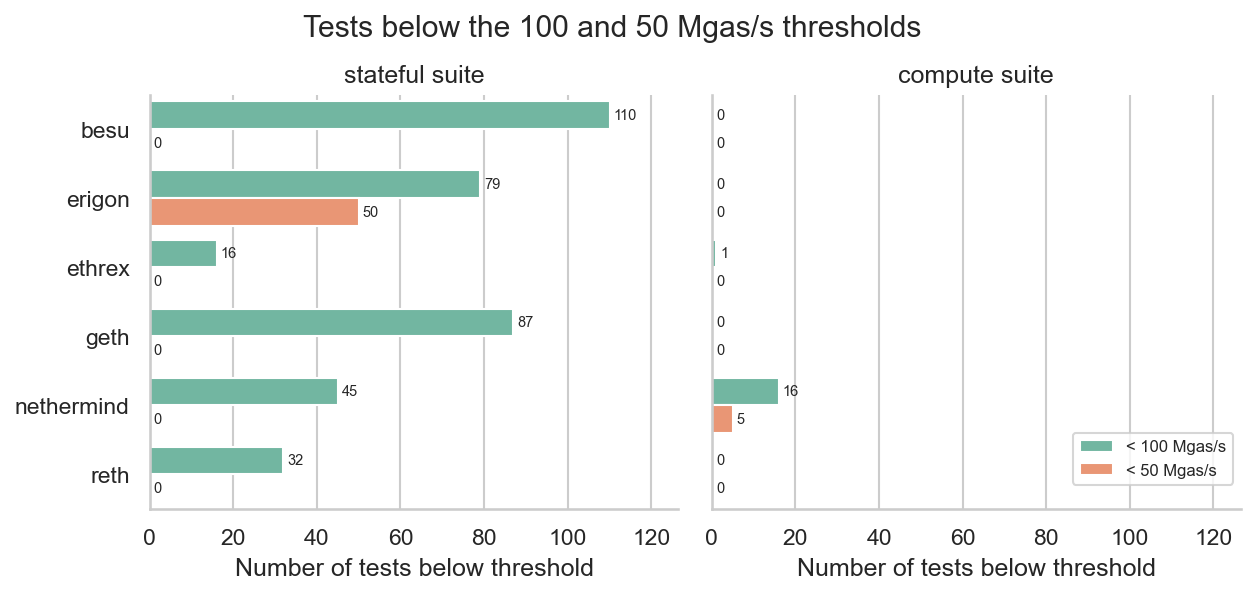

In [57]:
count_df = threshold_summary.melt(
    id_vars=["suite", "client"],
    value_vars=["n_below_anchor", "n_below_soft"],
    var_name="threshold",
    value_name="n_below",
).replace(
    {
        "n_below_anchor": f"< {ANCHOR_MGAS_S} Mgas/s",
        "n_below_soft": f"< {SOFT_MGAS_S} Mgas/s",
    }
)

g = sns.catplot(
    data=count_df,
    y="client",
    x="n_below",
    hue="threshold",
    order=CLIENT_ORDER,
    col="suite",
    col_order=SUITE_ORDER,
    kind="bar",
    height=3.8,
    aspect=1.15,
    legend_out=False,
)
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f", padding=2, fontsize=7)
    ax.margins(x=0.15)
g.set_titles("{col_name} suite")
g.set_xlabels("Number of tests below threshold")
g.set_ylabels("")
sns.move_legend(g, "lower right", title="", fontsize=8, bbox_to_anchor=(0.98, 0.20))
g.figure.suptitle(
    f"Tests below the {ANCHOR_MGAS_S} and {SOFT_MGAS_S} Mgas/s thresholds", y=1.04
)
plt.show()

**The observed misses concentrate in stateful workloads.** Every client has
stateful test medians below the anchor. Compute has fewer observed misses, but
Geth and Nethermind have incomplete coverage and no completed compute runs in
this snapshot, so this does not establish that they clear the full suite.

The coverage table shows repetition counts per test. In particular, a median based
on one measurement offers no evidence about repeatability. Near-threshold counts
can also change with the time window or build mix.

## 3. Per-test throughput distribution by client

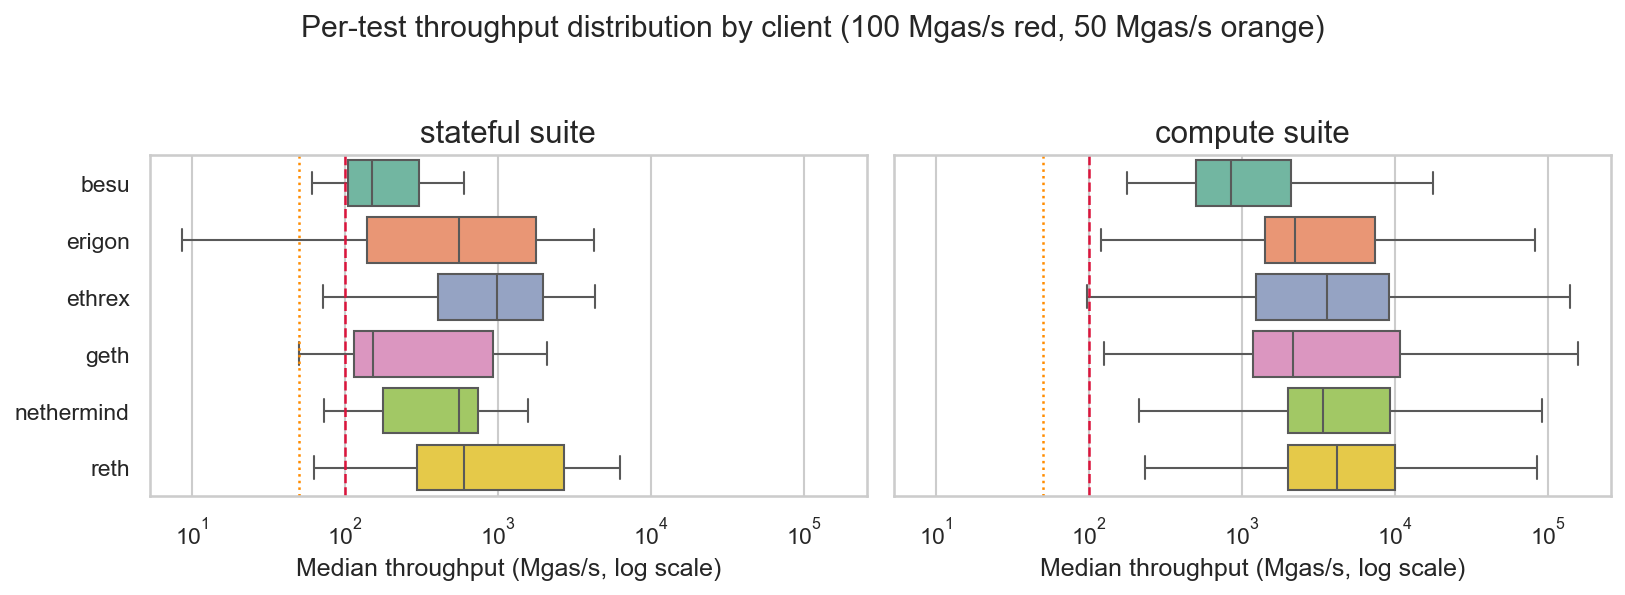

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharex=True)
for ax, suite in zip(axes, SUITE_ORDER):
    sns.boxplot(
        data=by_test_df[by_test_df["suite"] == suite],
        y="client",
        x="median_mgas_s",
        hue="client",
        hue_order=CLIENT_ORDER,
        order=CLIENT_ORDER,
        legend=False,
        showfliers=False,
        ax=ax,
    )
    ax.axvline(ANCHOR_MGAS_S, color="crimson", linestyle="--", linewidth=1.2)
    ax.axvline(SOFT_MGAS_S, color="darkorange", linestyle=":", linewidth=1.2)
    ax.set_xscale("log")
    ax.set_xlabel("Median throughput (Mgas/s, log scale)")
    ax.set_ylabel("")
    ax.set_title(f"{suite} suite")
axes[1].set_yticklabels([])
fig.suptitle(
    f"Per-test throughput distribution by client "
    f"({ANCHOR_MGAS_S} Mgas/s red, {SOFT_MGAS_S} Mgas/s orange)",
    y=1.04,
)
plt.tight_layout()
plt.show()

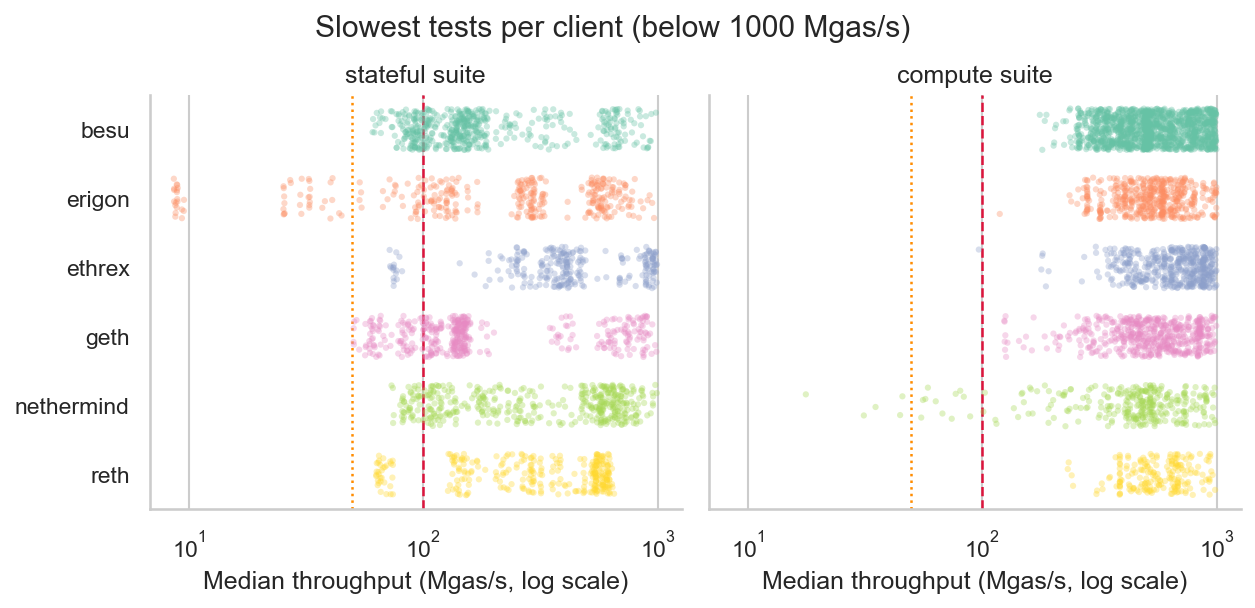

In [59]:
plot_df = by_test_df[by_test_df["median_mgas_s"] < 1000]

g = sns.catplot(
    data=plot_df,
    y="client",
    x="median_mgas_s",
    hue="client",
    hue_order=CLIENT_ORDER,
    order=CLIENT_ORDER,
    col="suite",
    col_order=SUITE_ORDER,
    kind="strip",
    alpha=0.35,
    size=3,
    jitter=0.3,
    legend=False,
    height=3.8,
    aspect=1.15,
)
for ax in g.axes.flat:
    ax.axvline(ANCHOR_MGAS_S, color="crimson", linestyle="--", linewidth=1.2)
    ax.axvline(SOFT_MGAS_S, color="darkorange", linestyle=":", linewidth=1.2)
    ax.set_xscale("log")
g.set_titles("{col_name} suite")
g.set_xlabels("Median throughput (Mgas/s, log scale)")
g.set_ylabels("")
g.figure.suptitle("Slowest tests per client (below 1000 Mgas/s)", y=1.04)
plt.show()

The boxes summarize the distribution of per-test medians, with outliers hidden;
the strip plots show individual test medians below 1,000 Mgas/s. These are
variations across benchmark cases, not confidence intervals or run-to-run noise.
Besu and Geth have lower stateful median throughput than the other clients in this
sample. A high median can coexist with severe misses in a smaller set of tests.

## 4. Where the thresholds break, by test function

Only functions with an observed test median below a threshold are shown. Cells
count observed misses, not failures or missing tests; clients can have different
coverage within a function. Use the coverage table when comparing counts.

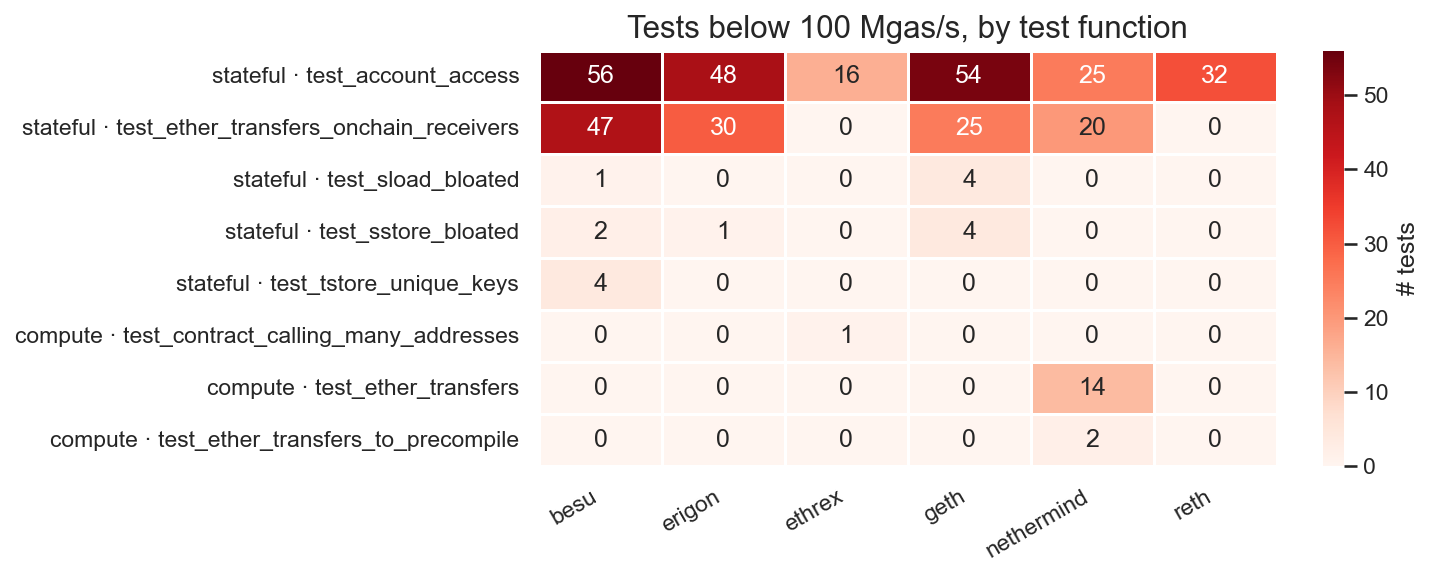

In [60]:
def plot_func_heatmap(flag: str, threshold: int) -> None:
    """Heatmap of tests below `threshold` per (suite, test function) and client."""
    pivot = by_test_df.pivot_table(
        index=["suite", "test_func"], columns="client", values=flag, aggfunc="sum"
    ).reindex(columns=CLIENT_ORDER)
    pivot = pivot[pivot.sum(axis=1) > 0].reindex(SUITE_ORDER, level="suite")
    if pivot.empty:
        print(f"No tests below {threshold} Mgas/s")
        return
    labels = [f"{suite} · {func}" for suite, func in pivot.index]

    fig, ax = plt.subplots(figsize=(10, max(2.2, 0.5 * len(pivot))))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".0f",
        cmap="Reds",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "# tests"},
        ax=ax,
    )
    ax.set_yticklabels(labels, rotation=0)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    ax.set_title(f"Tests below {threshold} Mgas/s, by test function")
    ax.set_ylabel("")
    ax.set_xlabel("")
    plt.tight_layout()
    plt.show()


plot_func_heatmap("below_anchor", ANCHOR_MGAS_S)

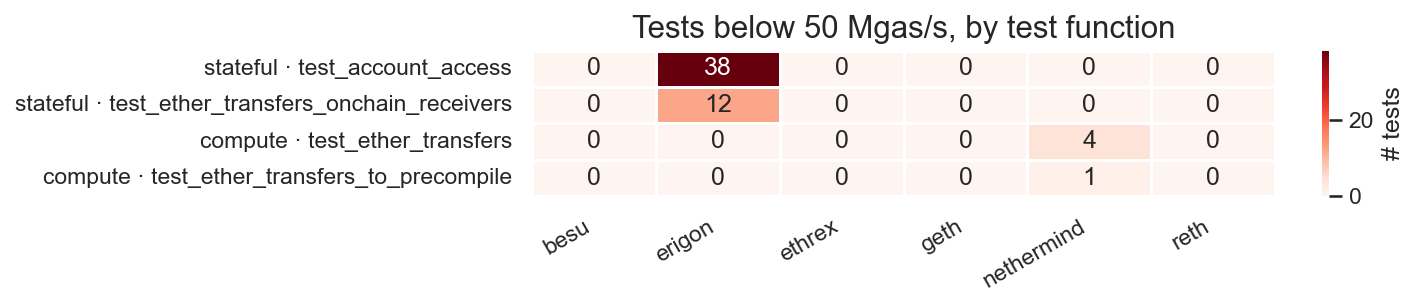

In [61]:
plot_func_heatmap("below_soft", SOFT_MGAS_S)

In [62]:
below_soft_df = by_test_df[by_test_df["below_soft"]].sort_values("median_mgas_s")
display(
    below_soft_df[
        [
            "suite",
            "client",
            "test_func",
            "test_params",
            "median_mgas_s",
            "min_mgas_s",
            "median_time_s",
            "n_runs",
        ]
    ]
    .assign(
        test_params=lambda d: d["test_params"].str.replace(
            "fork_Amsterdam-blockchain_test_stateful_engine-", "", regex=False
        ),
        median_mgas_s=lambda d: d["median_mgas_s"].round(1),
        min_mgas_s=lambda d: d["min_mgas_s"].round(1),
        median_time_s=lambda d: d["median_time_s"].round(2),
    )
    .reset_index(drop=True)
)

,suite,client,test_func,test_params,median_mgas_s,min_mgas_s,median_time_s,n_runs
0,stateful,erigon,test_account_access,code_size_65536-opcode_STATICCALL-value_sent_0...,8.6,8.5,34.68,17
1,stateful,erigon,test_account_access,code_size_65536-opcode_DELEGATECALL-value_sent...,8.7,8.5,34.60,17
2,stateful,erigon,test_account_access,code_size_65536-opcode_CALLCODE-value_sent_0-a...,8.7,8.6,34.59,17
3,stateful,erigon,test_account_access,code_size_65536-opcode_CALL-value_sent_0-accou...,8.7,8.6,34.57,17
4,stateful,erigon,test_account_access,code_size_65536-opcode_STATICCALL-value_sent_0...,8.8,8.7,34.19,17
5,stateful,erigon,test_account_access,code_size_65536-opcode_CALL-value_sent_0-accou...,8.8,8.7,34.18,17
6,stateful,erigon,test_account_access,code_size_65536-opcode_DELEGATECALL-value_sent...,8.8,8.7,34.09,17
7,stateful,erigon,test_account_access,code_size_65536-opcode_CALLCODE-value_sent_0-a...,8.8,8.7,34.03,17
8,stateful,erigon,test_account_access,code_size_65536-opcode_CALL-value_sent_0-accou...,8.9,8.8,22.47,17
9,stateful,erigon,test_account_access,code_size_65536-opcode_STATICCALL-value_sent_0...,8.9,8.8,22.47,17


The function heatmaps identify where observed misses occur. Stateful misses are
concentrated in account access and transfers to on-chain receivers. Erigon's
large-code cold-access cases are conspicuously slow, but the data alone do not
identify the cause or separate implementation, build, and configuration effects.
A cross-client gap warrants investigation; it does not by itself establish whether
gas pricing should change. The table above retains each case's measured throughput
and time rather than extrapolating to a different gas limit.

## 5. Tests targeting 200M gas: which have median time above six seconds?

`target_gas_m` is parsed from the test name. Actual gas used can be substantially
lower, so we compare **measured median execution time** with the six-second
budget and report the actual gas range. This is not a prediction for an exactly
200M-gas block. At exactly 200M gas, six seconds corresponds to 33.3 Mgas/s;
that is a less demanding throughput requirement than 50 Mgas/s.

In [63]:
gas_200m_df = by_test_df[by_test_df["target_gas_m"] == 200].copy()
gas_200m_df["over_budget"] = gas_200m_df["median_time_s"] > TIME_BUDGET_S
budget_summary = (
    gas_200m_df.groupby(["suite", "client"])
    .agg(
        observed_tests=("test_name", "size"),
        n_over_budget=("over_budget", "sum"),
        slowest_median_s=("median_time_s", "max"),
        median_s=("median_time_s", "median"),
        min_actual_gas=("min_gas_used", "min"),
        max_actual_gas=("max_gas_used", "max"),
    )
    .reindex(comparison_index)
)
display(budget_summary.round(2))

observed_tests  n_over_budget  slowest_median_s  \
suite    client                                                        
stateful besu                   266              0              3.28   
         erigon                 266             17             22.47   
         ethrex                 266              0              2.78   
         geth                   266              0              3.96   
         nethermind             266              0              2.73   
         reth                   266              0              3.17   
compute  besu                  1150              0              1.13   
         erigon                1150              0              1.68   
         ethrex                1150              0              2.07   
         geth                  1147              0              1.61   
         nethermind            1106              1              6.39   
         reth                  1150              0              0.86   

                     median_s  min_actual_gas  max_actual_gas  
suite    client                                                
stateful besu            1.41       168030238       200093445  
         erigon          0.36       168030238       200093445  
         ethrex          0.21       168030238       200093445  
         geth            1.39       168030238       200093445  
         nethermind      0.39       168030238       200093445  
         reth            0.36       168030238       200093445  
compute  besu            0.24       100453680       200000000  
         erigon          0.09       100453680       200000000  
         ethrex          0.06       100453680       200000000  
         geth            0.09       100453680       200000000  
         nethermind      0.06       100453680       200000000  
         reth            0.05       100453680       200000000

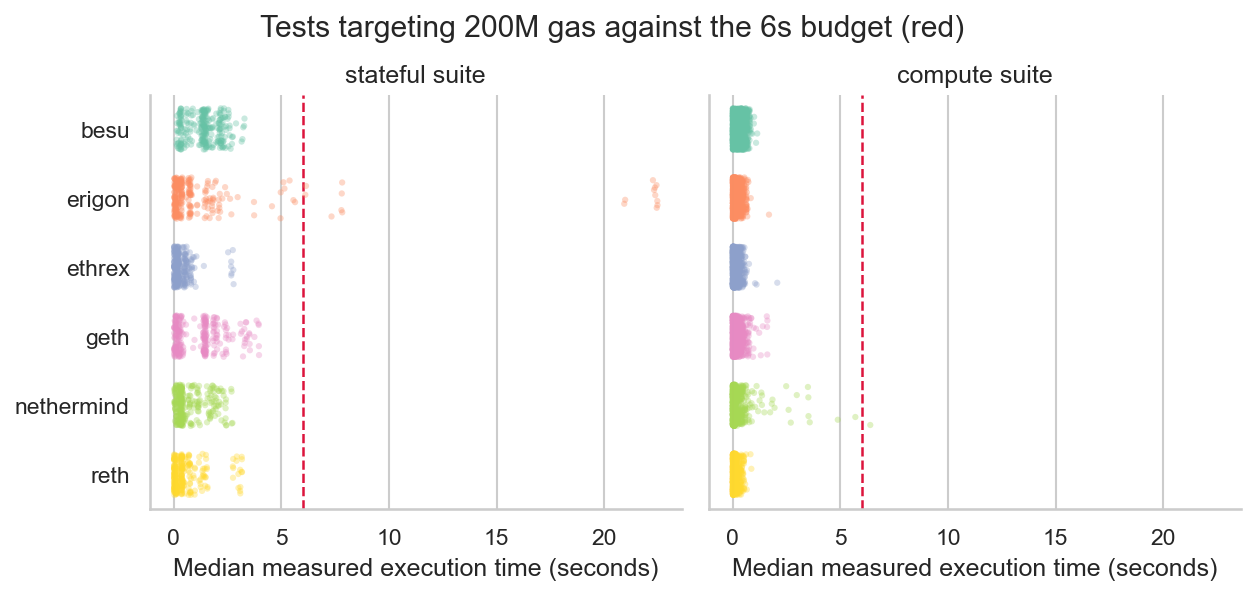

In [64]:
g = sns.catplot(
    data=gas_200m_df,
    y="client",
    x="median_time_s",
    hue="client",
    hue_order=CLIENT_ORDER,
    order=CLIENT_ORDER,
    col="suite",
    col_order=SUITE_ORDER,
    kind="strip",
    alpha=0.35,
    size=3,
    jitter=0.3,
    legend=False,
    height=3.8,
    aspect=1.15,
)
for ax in g.axes.flat:
    ax.axvline(TIME_BUDGET_S, color="crimson", linestyle="--", linewidth=1.2)
g.set_titles("{col_name} suite")
g.set_xlabels("Median measured execution time (seconds)")
g.set_ylabels("")
g.figure.suptitle(
    f"Tests targeting 200M gas against the {TIME_BUDGET_S}s budget (red)", y=1.04
)
plt.show()

In [65]:
over_budget_df = gas_200m_df[gas_200m_df["over_budget"]].sort_values(
    "median_time_s", ascending=False
)
print(
    f"{len(over_budget_df)} (suite, client, test) pairs have median time above {TIME_BUDGET_S}s"
)

display(
    over_budget_df[
        [
            "suite",
            "client",
            "test_func",
            "test_params",
            "median_time_s",
            "median_mgas_s",
            "n_runs",
            "min_gas_used",
            "max_gas_used",
        ]
    ]
    .assign(
        test_params=lambda d: d["test_params"].str.replace(
            "fork_Amsterdam-blockchain_test_stateful_engine-", "", regex=False
        ),
        median_time_s=lambda d: d["median_time_s"].round(2),
        median_mgas_s=lambda d: d["median_mgas_s"].round(1),
    )
    .reset_index(drop=True)
)

18 (suite, client, test) pairs have median time above 6s


,suite,client,test_func,test_params,median_time_s,median_mgas_s,n_runs,min_gas_used,max_gas_used
0,stateful,erigon,test_account_access,code_size_65536-opcode_CALL-value_sent_0-accou...,22.47,8.9,17,199998768,199998768
1,stateful,erigon,test_account_access,code_size_65536-opcode_STATICCALL-value_sent_0...,22.47,8.9,17,199998854,199998854
2,stateful,erigon,test_account_access,code_size_65536-opcode_DELEGATECALL-value_sent...,22.44,8.9,17,199998854,199998854
3,stateful,erigon,test_account_access,code_size_65536-opcode_CALLCODE-value_sent_0-a...,22.43,8.9,17,199998768,199998768
4,stateful,erigon,test_account_access,code_size_65536-opcode_CALL-value_sent_0-accou...,22.37,8.9,17,199996916,199996916
5,stateful,erigon,test_account_access,code_size_65536-opcode_STATICCALL-value_sent_0...,22.36,8.9,17,199998660,199998660
6,stateful,erigon,test_account_access,code_size_65536-opcode_DELEGATECALL-value_sent...,22.31,9.0,17,199998660,199998660
7,stateful,erigon,test_account_access,code_size_65536-opcode_CALLCODE-value_sent_0-a...,22.26,9.0,17,199996916,199996916
8,stateful,erigon,test_account_access,code_size_65536-opcode_EXTCODECOPY-value_sent_...,20.97,9.5,17,199997928,199997928
9,stateful,erigon,test_account_access,code_size_65536-opcode_EXTCODECOPY-value_sent_...,20.93,9.6,17,199997928,199997928


In [66]:
display(
    over_budget_df.pivot_table(
        index=["suite", "test_func"],
        columns="client",
        values="median_time_s",
        aggfunc="max",
    )
    .reindex(columns=CLIENT_ORDER)
    .round(2)
)

client                                           besu  erigon  ethrex  geth  \
suite    test_func                                                            
compute  test_ether_transfers                     NaN     NaN     NaN   NaN   
stateful test_account_access                      NaN   22.47     NaN   NaN   
         test_ether_transfers_onchain_receivers   NaN    6.14     NaN   NaN   

client                                           nethermind  reth  
suite    test_func                                                 
compute  test_ether_transfers                          6.39   NaN  
stateful test_account_access                            NaN   NaN  
         test_ether_transfers_onchain_receivers         NaN   NaN

The over-budget table reports **medians**, not the slowest recorded execution.
Erigon's cold account-access cases dominate this tail. Nethermind's compute
results come from partial runs; inspect `n_runs` before drawing conclusions from
an individual case. A single timing should be treated as provisional.

A lower rate cutoff selects fewer misses, and the exact rate corresponding to
five seconds depends on the **actual** gas used. The 200M target label alone does
not justify substituting a 40 Mgas/s filter for the measured-time comparison.

## Summary

The tables below are generated from the filtered data, so dates, counts, coverage,
and repetition ranges stay aligned when the notebook is rerun.

Stateful account access and receiver transfers deserve further investigation.
The observed compute suite has fewer throughput misses, but incomplete coverage
prevents a blanket pass claim. Client comparisons describe this run and build mix;
they do not establish a cause, an exact repricing factor, or performance at a
different block size. Partial runs and unequal repetitions limit the conclusions.

In [67]:
display(
    Markdown(
        f"**Run-start window:** [{WINDOW_START}, {AS_OF}). "
        f"**Measurements:** {len(raw_df):,} inside the window; {len(df):,} after the Besu instance filter. "
        f"**Budget:** {len(over_budget_df)} observed test/client pairs targeting 200M gas "
        f"have median measured time above {TIME_BUDGET_S} seconds."
    )
)
summary_table = threshold_summary.set_index(["suite", "client"])[
    [
        "observed_tests",
        "expected_tests",
        "unobserved_tests",
        "n_below_anchor",
        "pct_below_anchor",
        "n_below_soft",
        "pct_below_soft",
        "slowest_mgas_s",
        "median_mgas_s",
        "min_runs_per_test",
        "max_runs_per_test",
    ]
]
display(
    summary_table.rename(
        columns={
            "n_below_anchor": f"median < {ANCHOR_MGAS_S} Mgas/s",
            "n_below_soft": f"median < {SOFT_MGAS_S} Mgas/s",
            "slowest_mgas_s": "slowest test median (Mgas/s)",
            "median_mgas_s": "median across tests (Mgas/s)",
        }
    ).round(1)
)

**Run-start window:** [2026-09-03 00:00:00+00:00, 2026-09-08 00:00:00+00:00). **Measurements:** 662,047 inside the window; 480,551 after the Besu instance filter. **Budget:** 18 observed test/client pairs targeting 200M gas have median measured time above 6 seconds.

observed_tests  expected_tests  unobserved_tests  \
suite    client                                                         
stateful besu                   532             532                 0   
         erigon                 532             532                 0   
         ethrex                 532             532                 0   
         geth                   532             532                 0   
         nethermind             532             532                 0   
         reth                   532             532                 0   
compute  besu                  2300            2302                 2   
         erigon                2300            2302                 2   
         ethrex                2300            2302                 2   
         geth                  2293            2302                 9   
         nethermind            2218            2302                84   
         reth                  2300            2302                 2   

                     median < 100 Mgas/s  pct_below_anchor  \
suite    client                                              
stateful besu                        110              20.7   
         erigon                       79              14.8   
         ethrex                       16               3.0   
         geth                         87              16.4   
         nethermind                   45               8.5   
         reth                         32               6.0   
compute  besu                          0               0.0   
         erigon                        0               0.0   
         ethrex                        1               0.0   
         geth                          0               0.0   
         nethermind                   16               0.7   
         reth                          0               0.0   

                     median < 50 Mgas/s  pct_below_soft  \
suite    client                                           
stateful besu                         0             0.0   
         erigon                      50             9.4   
         ethrex                       0             0.0   
         geth                         0             0.0   
         nethermind                   0             0.0   
         reth                         0             0.0   
compute  besu                         0             0.0   
         erigon                       0             0.0   
         ethrex                       0             0.0   
         geth                         0             0.0   
         nethermind                   5             0.2   
         reth                         0             0.0   

                     slowest test median (Mgas/s)  \
suite    client                                     
stateful besu                                60.9   
         erigon                               8.6   
         ethrex                              72.0   
         geth                                50.5   
         nethermind                          73.4   
         reth                                63.1   
compute  besu                               176.3   
         erigon                             119.0   
         ethrex                              96.8   
         geth                               124.4   
         nethermind                          17.7   
         reth                               232.0   

                     median across tests (Mgas/s)  min_runs_per_test  \
suite    client                                                        
stateful besu                               150.3                  3   
         erigon                             557.2                 17   
         ethrex                             989.5                 15   
         geth                               152.2                 25   
         nethermind                         555.4                 17   
         reth                               605.9      